# Perceptrón

## Librerias

In [12]:
import numpy as np
import matplotlib.pyplot as plt

## Código

* Definimos la Función de Activación (Escalón / Step)

In [2]:
# Si la suma es > 0, devuelve 1. Si no, 0.
def step_function(x):
    return 1 if x >= 0 else 0

* Definimos los datos de entrenamiento, salidas esperadas, sesgos y pesos

In [9]:
# Datos de entrenamiento (Compuerta AND)
# Entradas [x1, x2]
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

# Salidas esperadas
y = np.array([0, 0, 0, 1])

# 3. Inicialización de Pesos y Sesgo (Bias)
# Los iniciamos aleatorios o en cero
weights = np.array([0.5, 0.5]) # Pesos iniciales (puedes jugar con estos)
bias = -0.7                    # Sesgo para mover el umbral

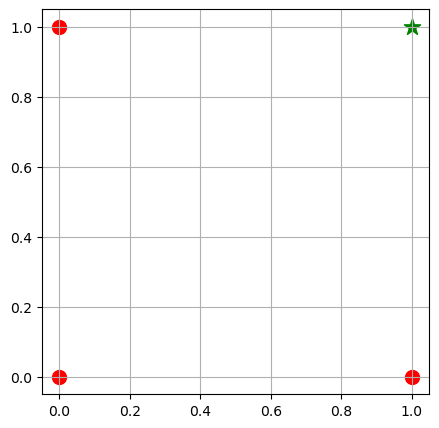

In [18]:
# Separar puntos por clase para colorearlos
ceros = X[y == 0]
unos = X[y == 1]

# Crear la gráfica
plt.figure(figsize=(5,5))
plt.scatter(ceros[:, 0], ceros[:, 1], color='red', s=100, label='Salida 0')
plt.scatter(unos[:, 0], unos[:, 1], color='green', marker='*', s=150, label='Salida 1')
plt.grid()
plt.show()


* Prediccion de la neurona

In [10]:

# 4. "Predicción" (Forward Pass)
print("--- Probando la Neurona ---")
for i in range(len(X)):
    entrada = X[i]
    # La fórmula mágica: (w1*x1 + w2*x2) + b
    suma_ponderada = np.dot(entrada, weights) + bias
    prediccion = step_function(suma_ponderada)

    print(f"Entrada: {entrada} -> Suma: {suma_ponderada:.2f} -> Predicción: {prediccion} (Esperado: {y[i]})")

# Nota para la clase:
# Explica que el 'Bias' negativo es necesario para que [0,0] no active la neurona
# y para mover la línea de decisión.

--- Probando la Neurona ---
Entrada: [0 0] -> Suma: -0.70 -> Predicción: 0 (Esperado: 0)
Entrada: [0 1] -> Suma: -0.20 -> Predicción: 0 (Esperado: 0)
Entrada: [1 0] -> Suma: -0.20 -> Predicción: 0 (Esperado: 0)
Entrada: [1 1] -> Suma: 0.30 -> Predicción: 1 (Esperado: 1)


![](image.png)

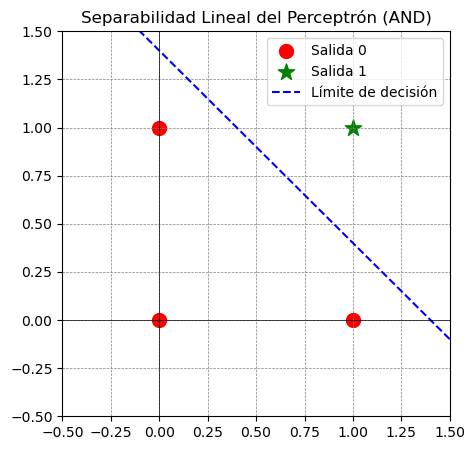

In [13]:
# Separar puntos por clase para colorearlos
ceros = X[y == 0]
unos = X[y == 1]

# Crear la gráfica
plt.figure(figsize=(5,5))
plt.scatter(ceros[:, 0], ceros[:, 1], color='red', s=100, label='Salida 0')
plt.scatter(unos[:, 0], unos[:, 1], color='green', marker='*', s=150, label='Salida 1')

# Dibujar la línea de decisión usando los pesos finales (w1, w2) y el bias (b)
# Fórmula despejada para el eje Y (x2): x2 = -(w1*x1 + b) / w2
x_linea = np.linspace(-0.5, 1.5, 100)
# Asumiendo que weights[0] es w1, weights[1] es w2 y bias es b (del código anterior)
y_linea = -(weights[0] * x_linea + bias) / weights[1]

plt.plot(x_linea, y_linea, color='blue', linestyle='--', label='Límite de decisión')

# Formato visual
plt.xlim(-0.5, 1.5)
plt.ylim(-0.5, 1.5)
plt.axhline(0, color='black',linewidth=0.5)
plt.axvline(0, color='black',linewidth=0.5)
plt.grid(color = 'gray', linestyle = '--', linewidth = 0.5)
plt.legend()
plt.title("Separabilidad Lineal del Perceptrón (AND)")
plt.show()

In [14]:
# Semilla para que siempre salga igual en la clase (opcional)
np.random.seed(63) 
weights = np.random.rand(2) # Dos pesos aleatorios entre 0 y 1
bias = np.random.rand(1)    # Un sesgo aleatorio
learning_rate = 0.1         # Qué tan rápido aprende (Tasa de aprendizaje)

# 3. El Bucle de Entrenamiento (Epochs)
print(f"Pesos Iniciales: {weights}, Bias: {bias}")
print("-" * 30)

epochs = 10 # Número de veces que revisará los datos

for epoch in range(epochs):
    error_total = 0
    
    for i in range(len(X)):
        entrada = X[i]
        target = y[i]
        
        # A. Predicción (Forward Pass)
        suma_ponderada = np.dot(entrada, weights) + bias
        prediccion = step_function(suma_ponderada)
        
        # B. Cálculo del Error
        error = target - prediccion
        
        # C. Actualización de Pesos (La magia matemática)
        # Regla: NuevoPeso = ViejoPeso + (Error * Tasa * Entrada)
        if error != 0:
            weights += error * learning_rate * entrada
            bias += error * learning_rate
            error_total += 1 # Contamos que hubo un error
            
    # Reporte por época (para que los alumnos vean el progreso)
    print(f"Época {epoch+1}: Errores = {error_total}")
    
    # Si ya no hay errores, terminamos antes
    if error_total == 0:
        print("-" * 30)
        print("¡Entrenamiento completado! La neurona aprendió.")
        break

print(f"\nPesos Finales: {weights}")
print(f"Bias Final: {bias}")

# 4. Prueba Final
print("\n--- Probando la Neurona Entrenada ---")
for i in range(len(X)):
    pred = step_function(np.dot(X[i], weights) + bias)
    print(f"Entrada: {X[i]} -> Predicción: {pred} (Esperado: {y[i]})")

Pesos Iniciales: [0.55394102 0.39624789], Bias: [0.04812677]
------------------------------
Época 1: Errores = 3
Época 2: Errores = 2
Época 3: Errores = 0
------------------------------
¡Entrenamiento completado! La neurona aprendió.

Pesos Finales: [0.35394102 0.19624789]
Bias Final: [-0.45187323]

--- Probando la Neurona Entrenada ---
Entrada: [0 0] -> Predicción: 0 (Esperado: 0)
Entrada: [0 1] -> Predicción: 0 (Esperado: 0)
Entrada: [1 0] -> Predicción: 0 (Esperado: 0)
Entrada: [1 1] -> Predicción: 1 (Esperado: 1)


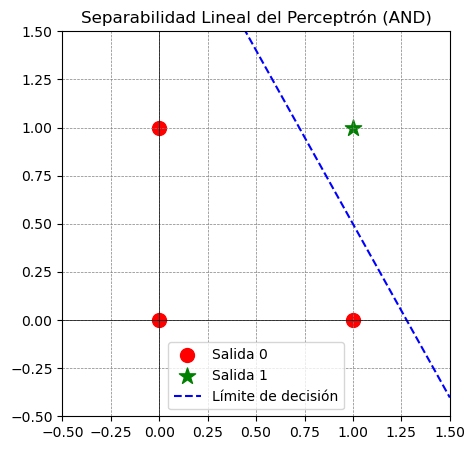

In [15]:
# Separar puntos por clase para colorearlos
ceros = X[y == 0]
unos = X[y == 1]

# Crear la gráfica
plt.figure(figsize=(5,5))
plt.scatter(ceros[:, 0], ceros[:, 1], color='red', s=100, label='Salida 0')
plt.scatter(unos[:, 0], unos[:, 1], color='green', marker='*', s=150, label='Salida 1')

# Dibujar la línea de decisión usando los pesos finales (w1, w2) y el bias (b)
# Fórmula despejada para el eje Y (x2): x2 = -(w1*x1 + b) / w2
x_linea = np.linspace(-0.5, 1.5, 100)
# Asumiendo que weights[0] es w1, weights[1] es w2 y bias es b (del código anterior)
y_linea = -(weights[0] * x_linea + bias) / weights[1]

plt.plot(x_linea, y_linea, color='blue', linestyle='--', label='Límite de decisión')

# Formato visual
plt.xlim(-0.5, 1.5)
plt.ylim(-0.5, 1.5)
plt.axhline(0, color='black',linewidth=0.5)
plt.axvline(0, color='black',linewidth=0.5)
plt.grid(color = 'gray', linestyle = '--', linewidth = 0.5)
plt.legend()
plt.title("Separabilidad Lineal del Perceptrón (AND)")
plt.show()